In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('weight-height.csv')

In [3]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


In [5]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


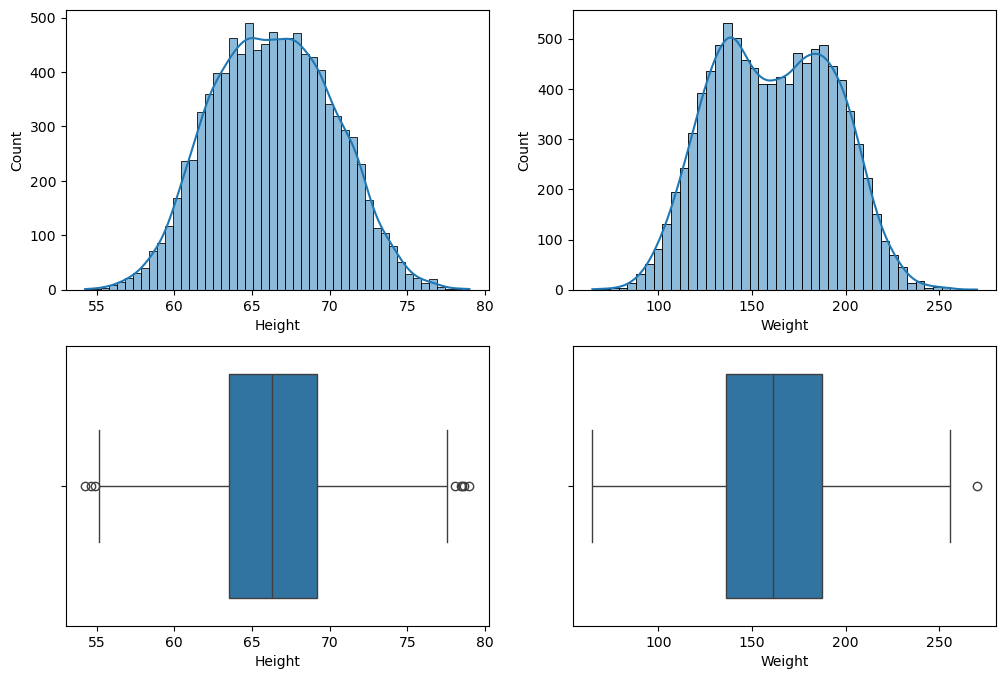

In [6]:
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
sns.histplot(df['Height'], kde=True)

plt.subplot(2,2,2)
sns.histplot(df['Weight'], kde=True)

plt.subplot(2,2,3)
sns.boxplot(df['Height'], orient='h')

plt.subplot(2,2,4)
sns.boxplot(df['Weight'], orient='h')
plt.show()

## Trimming

In [7]:
upper_limit = df['Height'].quantile(0.99)
lower_limit = df['Height'].quantile(0.01)

In [8]:
upper_limit

np.float64(74.7857900583366)

In [15]:
new_df = df[(df['Height']<upper_limit) & (df['Height']>lower_limit)]

<Axes: xlabel='Height'>

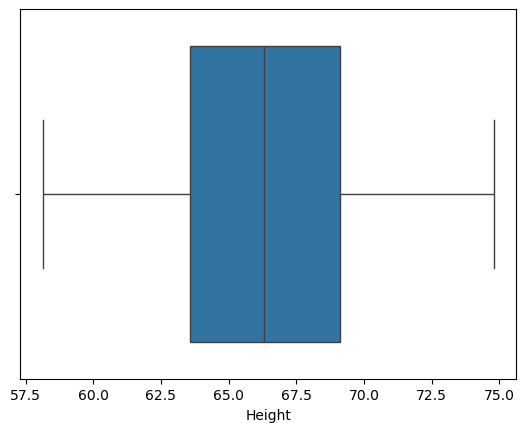

In [16]:
sns.boxplot(new_df['Height'], orient='h')

## capping or winsorization

In [18]:
df['Height'] = np.where(df['Height']>upper_limit, upper_limit,
        np.where(df['Height']<lower_limit, lower_limit, df['Height']))

In [21]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.366281,161.440357
std,3.795717,32.108439
min,58.134412,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,74.785790,269.989699
